# A2.6 Batch Normalization在参数优化中的作用
在本Notebook中，我将尝试探讨分析Batch normalization对参数优化起到什么作用，以及如何起到这种作用。下边我将结合数学推导、直观解释和可视化来解释这个问题。为了使这些概念更加具体,我们将使用CIFAR-10图像分类任务作为我们的运行示例。

## 1. Batch Normalization简介
在训练深层神经网络时，我们会遇到以下问题：

- **梯度消失和梯度爆炸**：随着网络层数的增加，梯度可能会在反向传播过程中逐渐消失或爆炸，导致训练困难。
- **内部协变量偏移（Internal Covariate Shift）**：模型参数更新后，每层的输入分布会发生变化，迫使后续层不断适应新的输入分布，降低了训练效率。
为了解决上述问题，Ioffe和Szegedy在2015年提出了Batch Normalization方法，通过在每一层对输入进行归一化，减轻内部协变量偏移，加速模型训练。它的主要目的是解决深度神经网络训练过程中的内部协变量偏移问题，从而加速网络训练并提高模型性能。

对于一个数据集$\{x_1, x_2, ..., x_m\}$，Batch Normalization的步骤如下：

1. **计算mini-batch的均值和方差**：
   $$
   \mu_B = \frac{1}{m} \sum_{i=1}^m x_i \\
   \sigma_B^2 = \frac{1}{m} \sum_{i=1}^m (x_i - \mu_B)^2
   $$
2. **归一化**：
   $$
   \hat{x}_i = \frac{x_i - \mu_B}{\sqrt{\sigma_B^2 + \epsilon}}
   $$
   其中，$\epsilon$是一个很小的常数，防止分母为零。
3. **缩放和平移**：
   $$
   y_i = \gamma \hat{x}_i + \beta
   $$
   其中，$\gamma$和$\beta$是可学习的参数，恢复数据的表达能力。

## 2. Batch Normalization的作用
Batch Normalization对参数优化起到了多方面的作用：
1. **减缓内部协变量偏移**：通过归一化每一层的输入，减少了前层参数变化对后层的影响，使得每一层的输入分布更加稳定。
2. **允许使用更高的学习率**：归一化操作使得优化landscapes更加平滑，允许我们使用更大的学习率而不会导致梯度爆炸或消失。
3. **减少对初始化的敏感性**：Batch Normalization在一定程度上减轻了网络对权重初始化的依赖。
4. **具有轻微的正则化效果**：由于每个mini-batch的统计量都有轻微的波动，这引入了一些噪声，起到了轻微的正则化作用。
5. **缓解梯度消失问题**：通过确保每一层的输入具有合适的尺度，有助于防止激活函数饱和，从而缓解梯度消失问题。

## 3、数学解释
### 3.1 反向传播中的梯度计算
在反向传播中，Batch Norm的梯度计算涉及链式法则，需要对归一化操作求导。
- **对$\hat{x}_i$的梯度**：
  $$
  \frac{\partial L}{\partial \hat{x}_i} = \gamma \frac{\partial L}{\partial y_i}
  $$
- **对$x_i$的梯度**：
  $$
  \frac{\partial L}{\partial x_i} = \frac{1}{\sqrt{\sigma_B^2 + \epsilon}} \left( \frac{\partial L}{\partial \hat{x}_i} - \frac{1}{m} \sum_{i=1}^m \frac{\partial L}{\partial \hat{x}_i} - \hat{x}_i \frac{1}{m} \sum_{i=1}^m \frac{\partial L}{\partial \hat{x}_i} \hat{x}_i \right)
  $$
### 3.2 稳定梯度传递
- **归一化的作用**：使得梯度不会因为激活值过大或过小而出现数值不稳定的情况。
- **均值和方差的共享**：在mini-batch内共享均值和方差，平滑了梯度的变化。

## 4. 实验与可视化

让我们通过一个简单的例子来实现Batch Normalization并可视化其效果。下面的代码实现了一个简单的神经网络，分别使用和不使用Batch Normalization进行训练，然后比较它们的训练损失和权重分布。

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torchvision import datasets, transforms

In [2]:
# 加载MNIST数据集
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.1307,), (0.3081,))])
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)

Failed to download (trying next):
<urlopen error [Errno 110] Connection timed out>



100%|██████████████████████████████████████████████████████████████████████████████| 9.91M/9.91M [00:05<00:00, 1.81MB/s]


Extracting ./data/MNIST/raw/train-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
<urlopen error [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: certificate has expired (_ssl.c:997)>



100%|███████████████████████████████████████████████████████████████████████████████| 28.9k/28.9k [00:00<00:00, 113kB/s]


Extracting ./data/MNIST/raw/train-labels-idx1-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
<urlopen error [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: certificate has expired (_ssl.c:997)>



100%|███████████████████████████████████████████████████████████████████████████████| 1.65M/1.65M [00:02<00:00, 808kB/s]


Extracting ./data/MNIST/raw/t10k-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
<urlopen error [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: certificate has expired (_ssl.c:997)>



100%|██████████████████████████████████████████████████████████████████████████████| 4.54k/4.54k [00:00<00:00, 15.2MB/s]

Extracting ./data/MNIST/raw/t10k-labels-idx1-ubyte.gz to ./data/MNIST/raw



In [3]:
# 定义网络
class Net(nn.Module):
    def __init__(self, use_bn=False):
        super(Net, self).__init__()
        self.fc1 = nn.Linear(784, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 10)
        self.use_bn = use_bn
        if use_bn:
            self.bn1 = nn.BatchNorm1d(256)
            self.bn2 = nn.BatchNorm1d(128)

    def forward(self, x):
        x = x.view(-1, 784)
        x = self.fc1(x)
        if self.use_bn:
            x = self.bn1(x)
        x = torch.relu(x)
        x = self.fc2(x)
        if self.use_bn:
            x = self.bn2(x)
        x = torch.relu(x)
        x = self.fc3(x)
        return x

In [4]:
# 训练函数
def train(model, optimizer, epochs):
    losses = []
    for epoch in range(epochs):
        for batch_idx, (data, target) in enumerate(train_loader):
            optimizer.zero_grad()
            output = model(data)
            loss = nn.functional.cross_entropy(output, target)
            loss.backward()
            optimizer.step()
            if batch_idx % 100 == 0:
                losses.append(loss.item())
    return losses

# 训练带BN和不带BN的网络
model_with_bn = Net(use_bn=True)
model_without_bn = Net(use_bn=False)

optimizer_with_bn = optim.SGD(model_with_bn.parameters(), lr=0.01, momentum=0.9)
optimizer_without_bn = optim.SGD(model_without_bn.parameters(), lr=0.01, momentum=0.9)

losses_with_bn = train(model_with_bn, optimizer_with_bn, 5)
losses_without_bn = train(model_without_bn, optimizer_without_bn, 5)

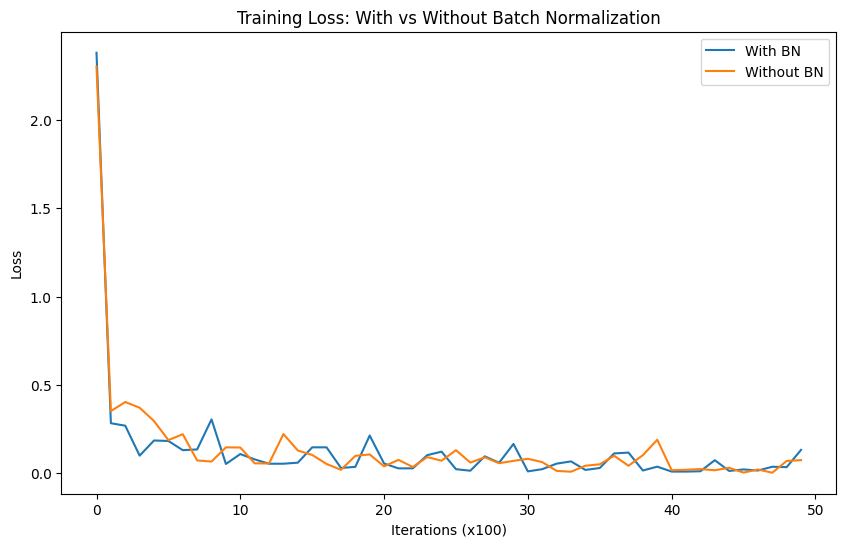

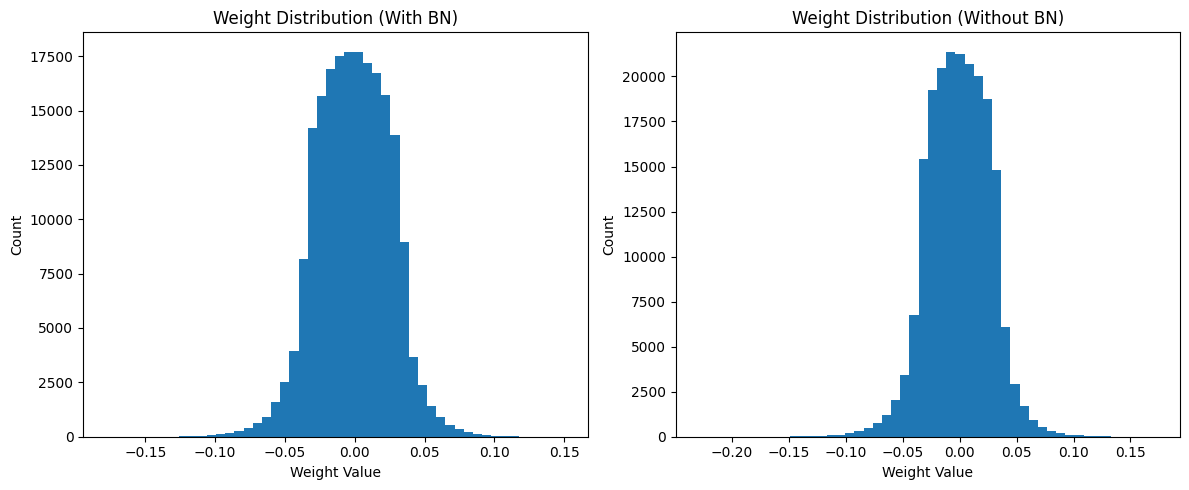

In [5]:
# 绘制损失曲线
plt.figure(figsize=(10, 6))
plt.plot(losses_with_bn, label='With BN')
plt.plot(losses_without_bn, label='Without BN')
plt.xlabel('Iterations (x100)')
plt.ylabel('Loss')
plt.title('Training Loss: With vs Without Batch Normalization')
plt.legend()
plt.show()

# 可视化第一层权重分布
plt.figure(figsize=(12, 5))

plt.subplot(121)
plt.hist(model_with_bn.fc1.weight.data.numpy().flatten(), bins=50)
plt.title('Weight Distribution (With BN)')
plt.xlabel('Weight Value')
plt.ylabel('Count')

plt.subplot(122)
plt.hist(model_without_bn.fc1.weight.data.numpy().flatten(), bins=50)
plt.title('Weight Distribution (Without BN)')
plt.xlabel('Weight Value')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

## 5. 结果分析
通过观察可视化的结果，不难作出以下结论：
1. **训练速度**：使用Batch Normalization的模型通常收敛更快，损失下降更迅速。
2. **最终性能**：在相同的训练轮数下，使用Batch Normalization的模型往往能达到更低的损失值。
3. **权重分布**：使用Batch Normalization的模型，其权重分布通常更加集中和规范，这反映了BN的正则化效果。
这恰好印证了上文中Batch Normalization的优势。